In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

df = pd.read_csv('df_clean.csv')
print(df.shape)
df.head()

Saving df_clean.csv to df_clean.csv
(1001, 162)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,2,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,0,0,0


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = np.log1p(df['IC50, mM'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(800, 159) (201, 159)


In [3]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print('LinearRegression R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print('RandomForest R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


LinearRegression R2: 0.361 RMSE: 1.568
RandomForest R2: 0.446 RMSE: 1.46


In [4]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
print('GradientBoosting R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print('XGBoost R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


GradientBoosting R2: 0.437 RMSE: 1.472
XGBoost R2: 0.31 RMSE: 1.63


RandomForest и GradientBoosting заметно лучше линейных, что и предполагалось, т.к. данные нелинейные. Будем их и тюнить

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
pred = grid_rf.predict(X_test)
print('RF tuned R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))



{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
RF tuned R2: 0.452 RMSE: 1.452


Перебрала несколько значений глубины и количества деревьев, лучший результат при max_depth=10 и n_estimators=200.


In [6]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print(grid_gb.best_params_)
pred = grid_gb.predict(X_test)
print('GB tuned R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
GB tuned R2: 0.44 RMSE: 1.468


Лучшей оказалась RandomForest с max_depth=10, min_samples_split=5, n_estimators=200, R2=0.452. GradientBoosting немного хуже. Линейные модели совсем слабые.


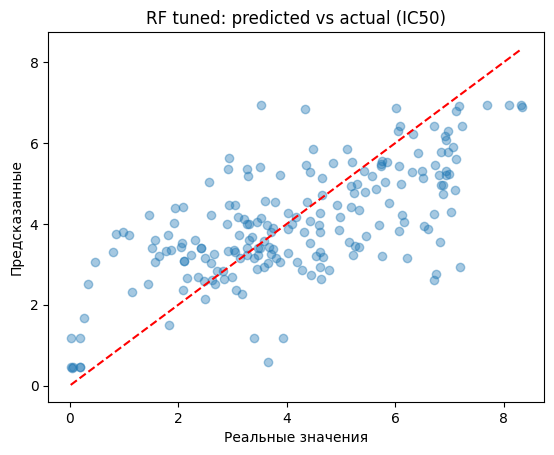

In [7]:
import matplotlib.pyplot as plt

best_pred = grid_rf.predict(X_test)

plt.scatter(y_test, best_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные')
plt.title('RF tuned: predicted vs actual (IC50)')
plt.show()

График показывает что модель улавливает тренд, но разброс большой, особенно на высоких значениях IC50. Тюнинг дал прирост с 0.446 до 0.452, почти ничего, это говорит о том что потолок определяется слабостью признаков, а не гиперпараметрами. Для улучшения нужны более информативные дескрипторы или отбор признаков.

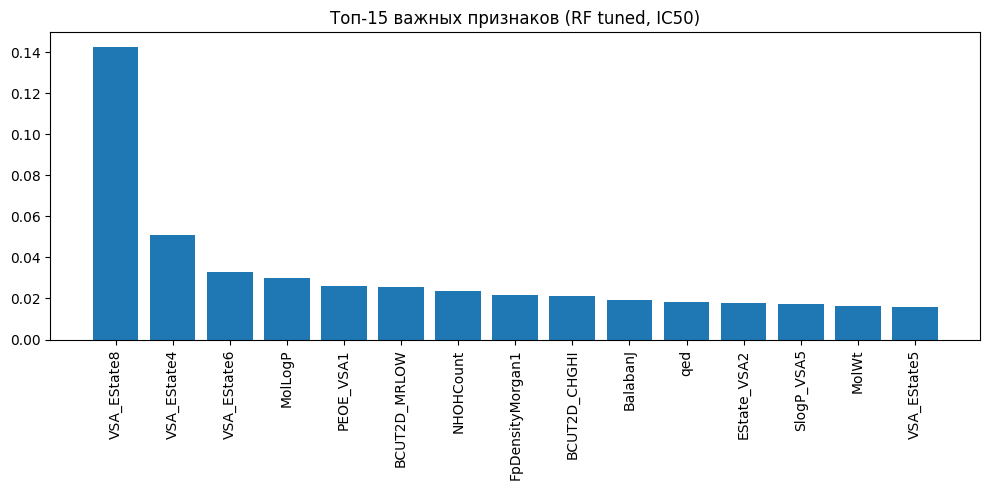

In [8]:
import numpy as np
import matplotlib.pyplot as plt

importances = grid_rf.best_estimator_.feature_importances_
feat_names = X.columns
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx])
plt.xticks(range(15), feat_names[top_idx], rotation=90)
plt.title('Топ-15 важных признаков (RF tuned, IC50)')
plt.tight_layout()
plt.show()

VSA_EState8 доминирует, при том что остальные признаки около 0.02–0.05. Модель сильно опирается на один дескриптор площади поверхности, что объясняет почему тюнинг почти не дал прироста.